# Whisker-Pole Collision Classifier — Training

Fine-tune an **EfficientNet-B3** (~14 M params) for binary classification:
- **1** = whisker contacts pole
- **0** = no contact

**Features:**
- ImageNet-pretrained backbone
- Albumentations augmentation (flip, rotate, brightness, blur, cutout)
- Binary Cross-Entropy with Logits loss
- Cosine-annealing LR schedule
- Early stopping on validation loss
- Saves best model checkpoint

In [1]:
import sys, os
from pathlib import Path
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, random_split
import matplotlib.pyplot as plt

TRAINING_DIR = os.path.dirname(os.path.abspath("__file__"))
if TRAINING_DIR not in sys.path:
    sys.path.insert(0, TRAINING_DIR)

from dataset import ContactDataset, get_train_transforms, get_val_transforms
from trainer import (
    build_model,
    count_parameters,
    train_one_epoch,
    evaluate,
    EarlyStopping,
    save_checkpoint,
    plot_epoch_confusion_matrices,
)

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch 2.7.1+cu126
CUDA available: True


## 1 — Configuration

In [2]:
# ========================  PATHS  ========================

# ========================  PATHS  ========================

# Root folder containing per-experiment pickles created by the Create Dataset notebook
CONTACT_ROOT_DIR = "/mnt/c/Users/wanglab/Desktop/Club Like Endings/COLLISION_DATASET"

# Automatically discover all per-experiment contact_dataset.pkl files
ALL_PKLS = sorted(str(p) for p in Path(CONTACT_ROOT_DIR).glob("*/contact_dataset.pkl"))

print("Found per-experiment pkls:")
for p in ALL_PKLS:
    print("  ", p)

if len(ALL_PKLS) == 0:
    raise RuntimeError(f"No contact_dataset.pkl files found under {CONTACT_ROOT_DIR}")

# 80:20 train/val split from each experiment (reproducible)
TRAIN_RATIO = 0.8
SPLIT_SEED = 42

# Where to save model checkpoints
SAVE_DIR = os.path.join(TRAINING_DIR, "checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)

# ========================  HYPERPARAMETERS  ========================

IMG_SIZE       = 256       # final input size for the model
BATCH_SIZE     = 32
NUM_WORKERS    = 2   # use 2 to avoid DataLoader warning on this system
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-4
EPOCHS         = 50
PATIENCE       = 10        # early stopping patience
FREEZE_BACKBONE = False    # set True for staged fine-tuning

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Save dir: {SAVE_DIR}")

Found per-experiment pkls:
   /mnt/c/Users/wanglab/Desktop/Club Like Endings/COLLISION_DATASET/102225_1/contact_dataset.pkl
   /mnt/c/Users/wanglab/Desktop/Club Like Endings/COLLISION_DATASET/102525_1/contact_dataset.pkl
   /mnt/c/Users/wanglab/Desktop/Club Like Endings/COLLISION_DATASET/102625_1/contact_dataset.pkl
   /mnt/c/Users/wanglab/Desktop/Club Like Endings/COLLISION_DATASET/102725_1/contact_dataset.pkl
Device: cuda
Save dir: /home/wanglab/Deep-Learning/Collision Classification/Training/checkpoints


## 2 — Load Datasets & DataLoaders

In [3]:
# 80:20 train/val from each experiment (same indices per pkl, different transforms for train vs val)
from torch.utils.data import Subset
gen = torch.Generator().manual_seed(SPLIT_SEED)
train_parts, val_parts = [], []
for pkl_path in ALL_PKLS:
    ds = ContactDataset(pkl_path, transform=None)
    n = len(ds)
    n_train = int(n * TRAIN_RATIO)
    n_val = n - n_train
    train_sub, val_sub = random_split(ds, [n_train, n_val], generator=gen)
    ds_train = ContactDataset(pkl_path, transform=get_train_transforms(IMG_SIZE))
    ds_val = ContactDataset(pkl_path, transform=get_val_transforms(IMG_SIZE))
    train_parts.append(Subset(ds_train, train_sub.indices))
    val_parts.append(Subset(ds_val, val_sub.indices))

train_ds = ConcatDataset(train_parts)
val_ds = ConcatDataset(val_parts)

# Collect train labels for class weighting (from underlying ContactDataset.labels)
train_labels = np.concatenate([
    np.array(part.dataset.labels)[part.indices] for part in train_parts
])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 17,691
Val samples   : 4,424
Train batches : 553
Val batches   : 139


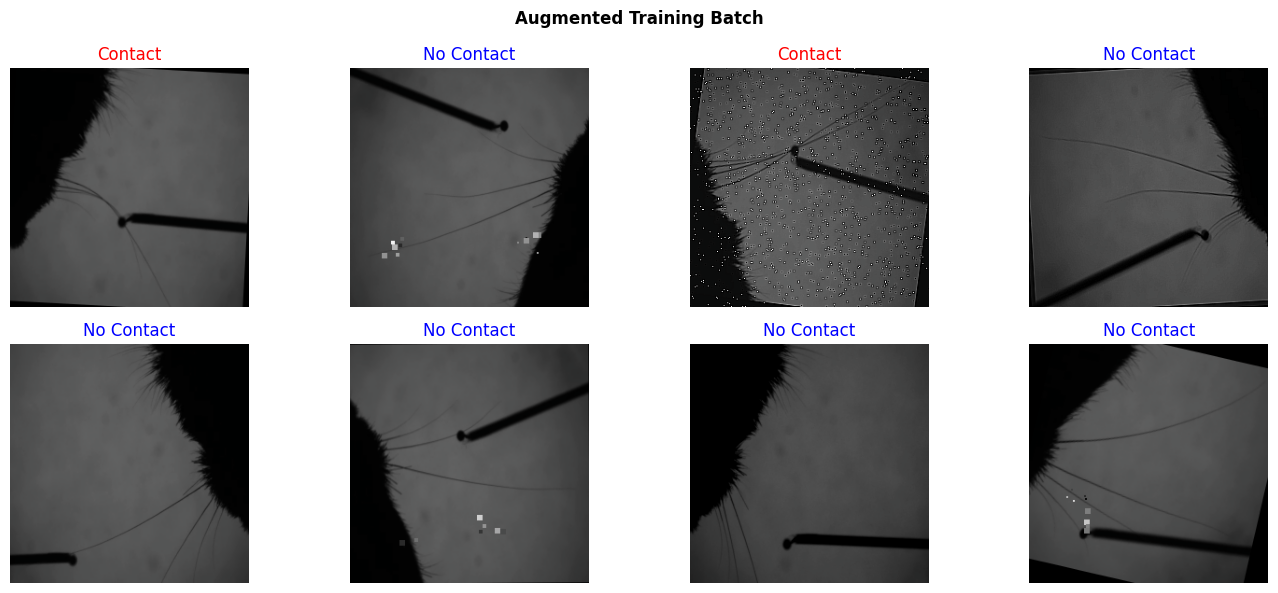

In [4]:
# Quick visual sanity check — show a batch of augmented images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i, ax in enumerate(axes.flatten()):
    if i >= len(images):
        break
    img = images[i].permute(1, 2, 0).numpy()  # C,H,W → H,W,C
    img = np.clip(img * std + mean, 0, 1)      # un-normalize
    lbl = int(labels[i].item())
    ax.imshow(img)
    ax.set_title("Contact" if lbl else "No Contact",
                 color="red" if lbl else "blue")
    ax.axis("off")

plt.suptitle("Augmented Training Batch", fontweight="bold")
plt.tight_layout()
plt.show()

## 3 — Build Model

In [5]:
model = build_model(
    num_classes=1,
    pretrained=True,
    dropout=0.3,
    freeze_backbone=FREEZE_BACKBONE,
).to(DEVICE)

params = count_parameters(model)
print(f"Total params     : {params['total']:,}")
print(f"Trainable params : {params['trainable']:,}")

Total params     : 11,483,689
Trainable params : 11,483,689


## 4 — Loss, Optimizer, Scheduler

In [6]:
# Compute class weight for imbalanced data (train_labels from 80% split of each experiment)

n_pos = (train_labels == 1).sum()
n_neg = (train_labels == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"Class counts — Contact: {n_pos}, No Contact: {n_neg}")
print(f"pos_weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

early_stopping = EarlyStopping(patience=PATIENCE, mode="min")

Class counts — Contact: 5765, No Contact: 11926
pos_weight: 2.07


## 5 — Training Loop


Epoch 1/50  (lr=1.00e-04)


  Train — loss: 0.1802  acc: 0.9492
  Val   — loss: 0.0221  acc: 0.9928  f1: 0.9884  prec: 0.9771  rec: 1.0000


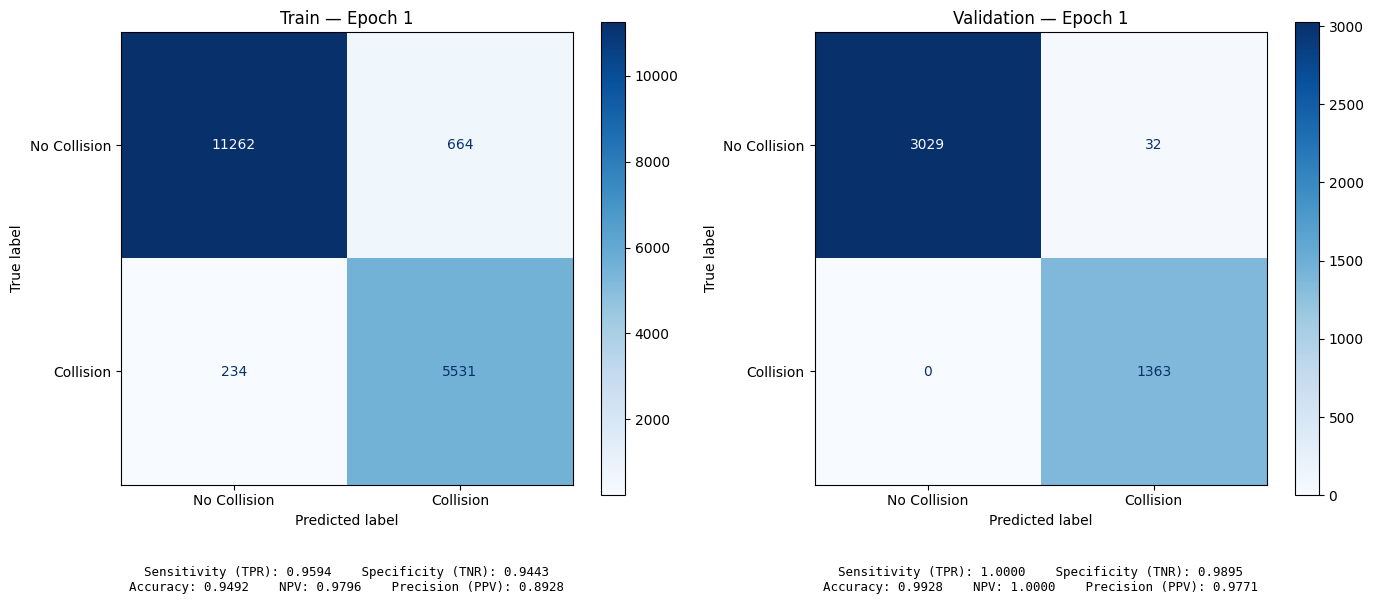

  💾 Checkpoint saved → /home/wanglab/Deep-Learning/Collision Classification/Training/checkpoints/contact_classifier.pt  (132.2 MB)

Epoch 2/50  (lr=9.99e-05)


  Train — loss: 0.0584  acc: 0.9838
  Val   — loss: 0.0087  acc: 0.9975  f1: 0.9960  prec: 0.9920  rec: 1.0000


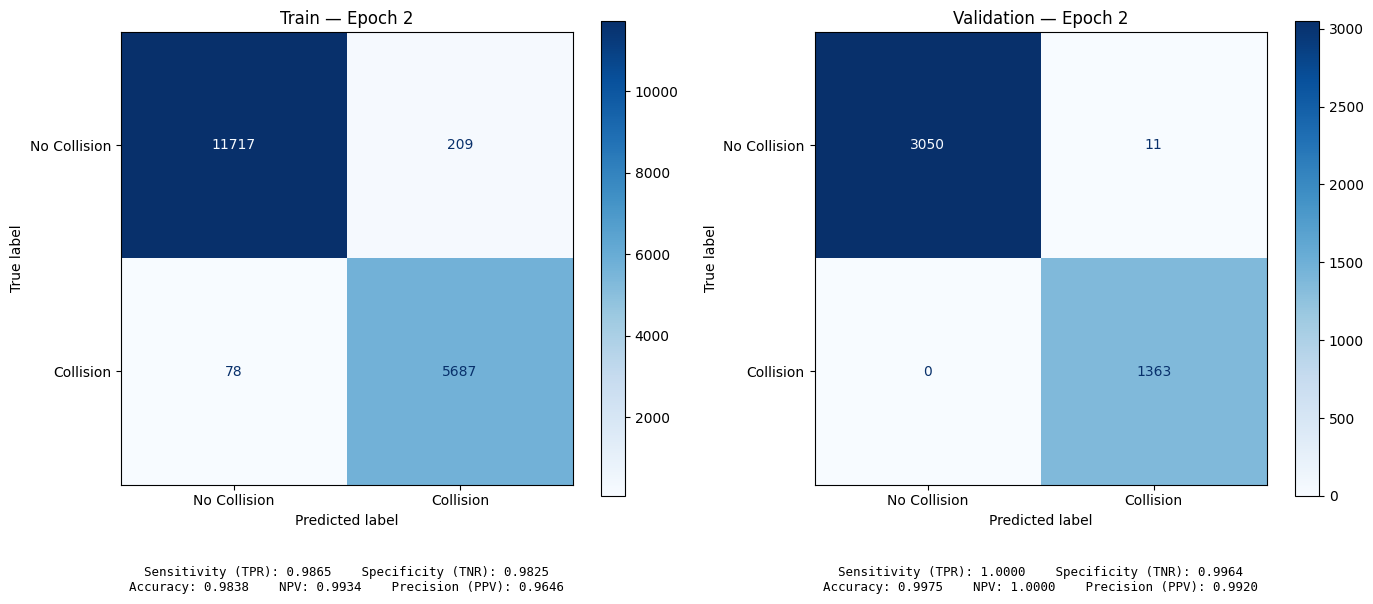

  💾 Checkpoint saved → /home/wanglab/Deep-Learning/Collision Classification/Training/checkpoints/contact_classifier.pt  (132.2 MB)

Epoch 3/50  (lr=9.96e-05)


  Train — loss: 0.0432  acc: 0.9884
  Val   — loss: 0.0095  acc: 0.9962  f1: 0.9938  prec: 0.9877  rec: 1.0000


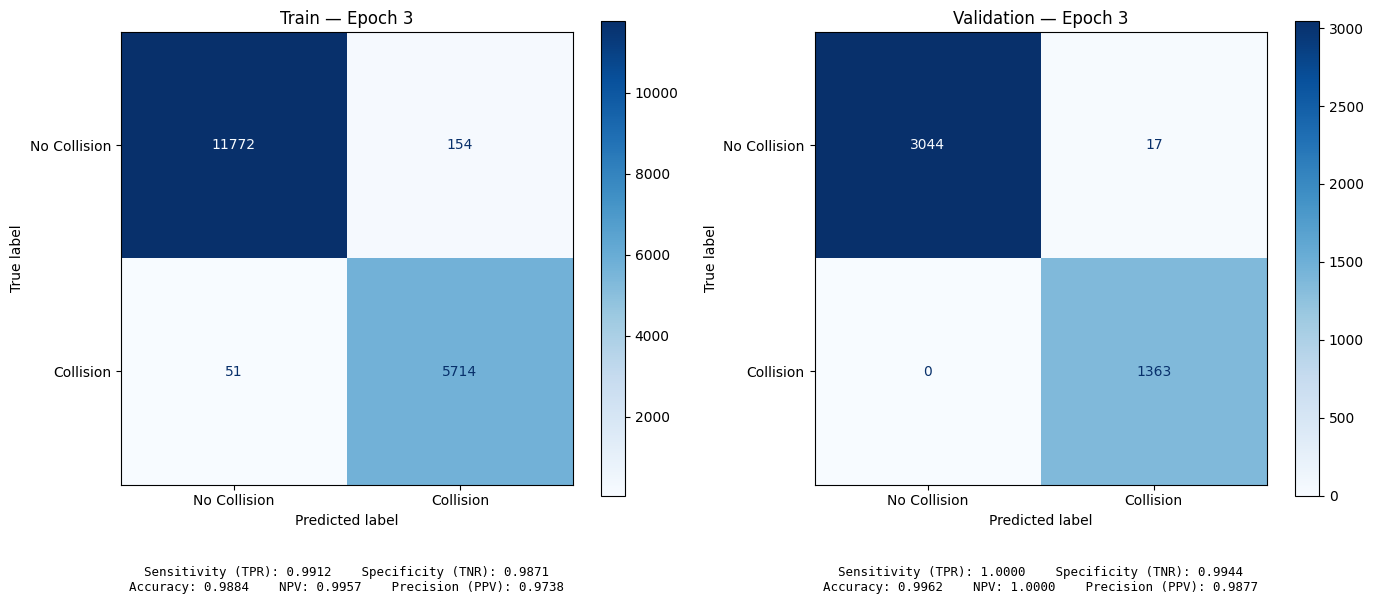


Epoch 4/50  (lr=9.91e-05)


  Train — loss: 0.0327  acc: 0.9908
  Val   — loss: 0.0047  acc: 0.9993  f1: 0.9989  prec: 0.9978  rec: 1.0000


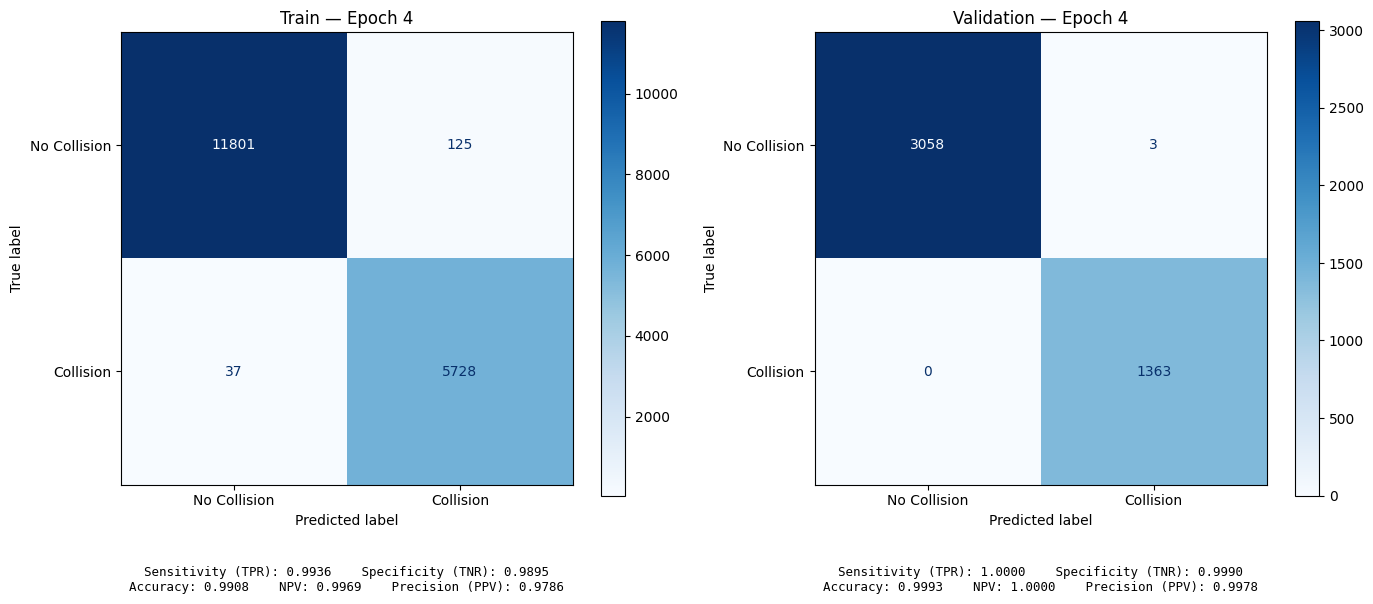

  💾 Checkpoint saved → /home/wanglab/Deep-Learning/Collision Classification/Training/checkpoints/contact_classifier.pt  (132.2 MB)

Epoch 5/50  (lr=9.84e-05)


  Train — loss: 0.0269  acc: 0.9930
  Val   — loss: 0.0062  acc: 0.9989  f1: 0.9982  prec: 0.9963  rec: 1.0000


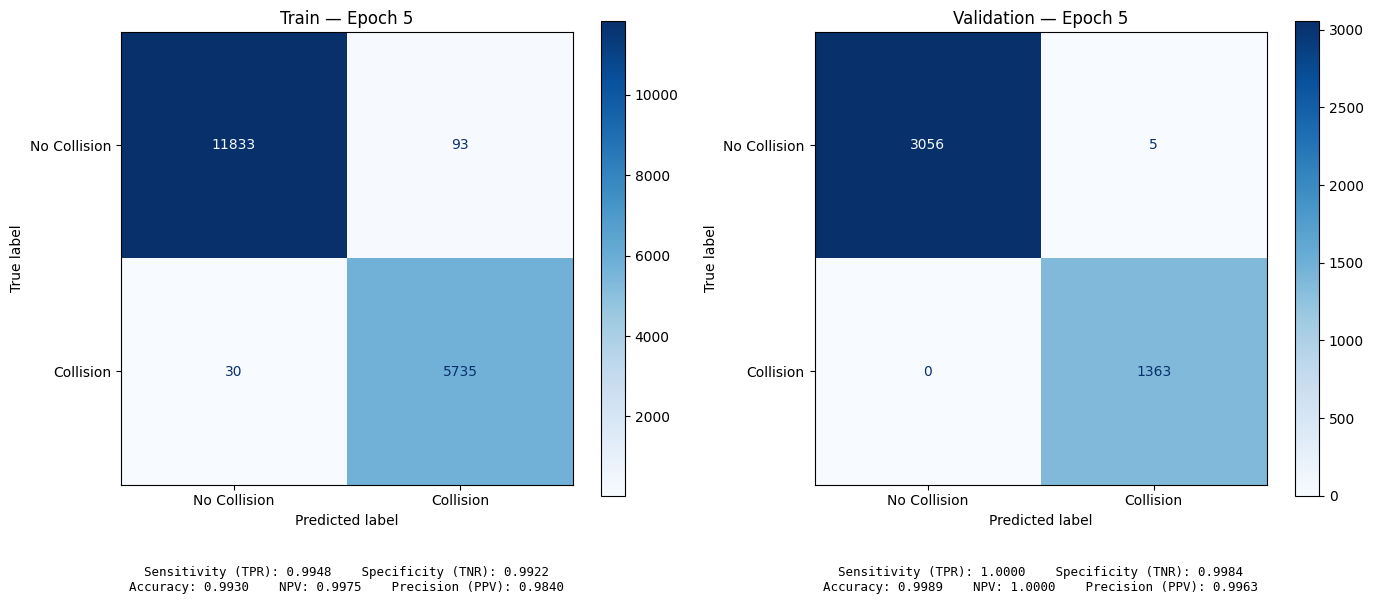


Epoch 6/50  (lr=9.76e-05)


  Train — loss: 0.0244  acc: 0.9928
  Val   — loss: 0.0061  acc: 0.9982  f1: 0.9971  prec: 0.9942  rec: 1.0000


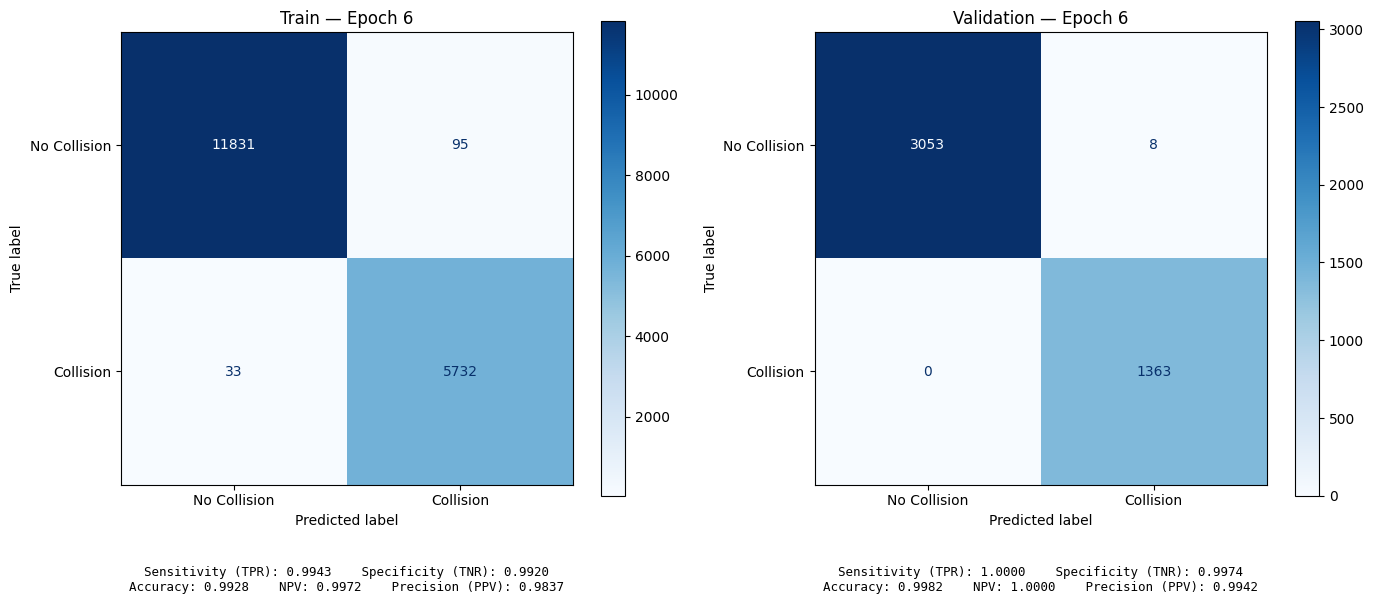


Epoch 7/50  (lr=9.65e-05)


  Train — loss: 0.0220  acc: 0.9946
  Val   — loss: 0.0050  acc: 0.9984  f1: 0.9974  prec: 0.9949  rec: 1.0000


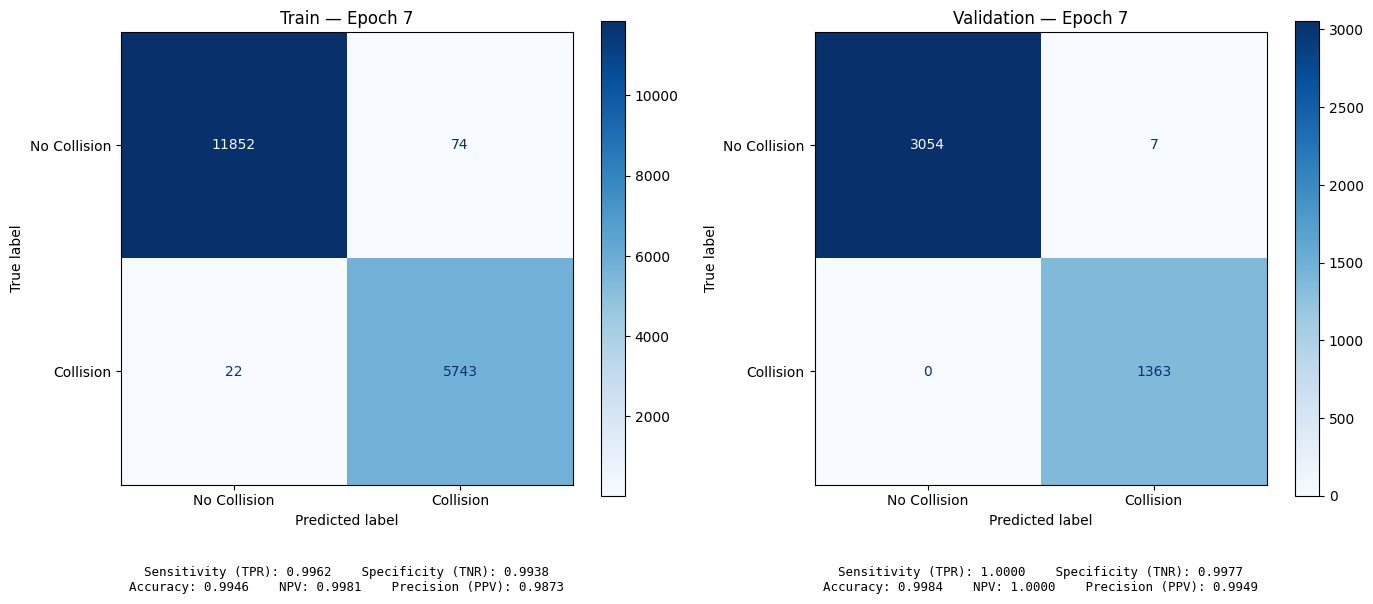


Epoch 8/50  (lr=9.53e-05)


KeyboardInterrupt: 

In [7]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
ckpt_path = os.path.join(SAVE_DIR, "contact_classifier.pt")
cm_dir = os.path.join(SAVE_DIR, "confusion_matrices")

config = {
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "freeze_backbone": FREEZE_BACKBONE,
    "model_arch": "efficientnet_b3",
}

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}  (lr={optimizer.param_groups[0]['lr']:.2e})")

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scheduler)
    val_metrics   = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    print(f"  Train — loss: {train_metrics['loss']:.4f}  acc: {train_metrics['accuracy']:.4f}")
    print(f"  Val   — loss: {val_metrics['loss']:.4f}  acc: {val_metrics['accuracy']:.4f}  "
          f"f1: {val_metrics['f1']:.4f}  prec: {val_metrics['precision']:.4f}  "
          f"rec: {val_metrics['recall']:.4f}")

    # Confusion matrix callback — plot train & val each epoch
    plot_epoch_confusion_matrices(
        train_labels=train_metrics["labels"],
        train_preds=train_metrics["preds"],
        val_labels=val_metrics["labels"],
        val_preds=val_metrics["preds"],
        epoch=epoch,
        save_dir=cm_dir,
    )

    # Early stopping check — saves checkpoint to disk when loss improves
    improved = early_stopping(val_metrics["loss"], model)
    if improved:
        save_checkpoint(model, optimizer, epoch, val_metrics["loss"],
                        history, config, ckpt_path)

    if early_stopping.should_stop:
        print(f"\n⏹  Early stopping triggered after {epoch} epochs.")
        break

# Restore best model weights
if early_stopping.best_model_state is not None:
    model.load_state_dict(early_stopping.best_model_state)
    print(f"\nRestored best model (val_loss = {early_stopping.best_score:.4f})")
    print(f"Best checkpoint saved at: {ckpt_path}")